# Analyse-data

L’objectif du notebook est d’analyser de manière rigoureuse et reproductible les performances des algorithmes PSO, GA et RANDOMSEARCH-5 sur les fonctions BBOB (f1, f8, f15, f20, f24) en dimension 20, à partir des fichiers .dat bruts issus de COCO. Il doit permettre de visualiser la convergence, agréger les runs, comparer les algorithmes et produire les figures/statistiques nécessaires au rapport scientifique et à la soutenance, conformément au protocole expérimental demandé par le séminaire.

## 1. Imports et paramètres globaux

In [189]:
import os
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import iqr, wilcoxon
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 11

ALGORITHMS = ["PSO", "RANDOMSEARCH-5", "GA"]
PROBLEMS = ["f1", "f8", "f15", "f20", "f24"]
DIMENSION = 20

BUDGET_LEVELS = {
    "petit": 100 * DIMENSION,
    "moyen": 1000 * DIMENSION,
    "grand": 10000 * DIMENSION
}

## 2. Configuration des chemins des fichiers

**Utilité générale de la courbe :** Une courbe de convergence montre l'évolution de la performance d'un algorithme au fil des évaluations, permettant d'observer la vitesse et la qualité de l'optimisation.

**Dans notre cas :** Cette courbe illustre la trajectoire d'un run unique de l'algorithme sur un problème BBOB, révélant les fluctuations stochastiques et la progression vers l'optimum. Elle sert à identifier des comportements atypiques ou des phases de stagnation, essentiels pour comprendre la dynamique de l'algorithme sur ce problème spécifique.

In [190]:
ROOT_DIR = Path('__file__').resolve().parent
DATA_DIRS = {
    "PSO": ROOT_DIR / "data_archive_pso",
    "RANDOMSEARCH-5": ROOT_DIR / "data_archive_RANDOMSEARCH-5",
    "GA": ROOT_DIR / "data_archive-GA",
}
FILE_PATTERNS = {
    "PSO": "bbobexp_{problem}_DIM20.dat",
    "RANDOMSEARCH-5": "bbobexp_{problem}_DIM20_i1.dat",
    "GA": "bbobexp_{problem}_DIM20.dat",
}

file_paths = {}
for algo, data_dir in DATA_DIRS.items():
    file_paths[algo] = {}
    for problem in PROBLEMS:
        filename = FILE_PATTERNS[algo].format(problem=problem)
        path = data_dir / filename
        file_paths[algo][problem] = str(path)
        if not path.exists():
            warnings.warn(
                f"Fichier introuvable pour {algo} {problem} : {path}",
                UserWarning,
            )

## 3. Vérification des chemins
Analyse et validation des chemins d'accès aux fichiers `.dat` avant le traitement.

In [191]:
def validate_file_paths(file_paths):
    errors = []
    for algo, problem_dict in file_paths.items():
        for problem, path in problem_dict.items():
            if "INSERER_ICI" in path:
                errors.append(f"[A REMPLIR] {algo} - {problem} : chemin non renseigné")
            elif not Path(path).exists():
                errors.append(f"[INTROUVABLE] {algo} - {problem} : {path}")
    return errors

errors = validate_file_paths(file_paths)

if errors:
    print("Des problèmes ont été détectés :")
    for err in errors:
        print(" -", err)
else:
    print("Tous les chemins semblent valides.")

Tous les chemins semblent valides.


## 4. Parsing des fichiers `.dat` BBOB
Fonctions de lecture et de conversion des fichiers bruts en jeux de données structurés.

In [192]:
# ============================================================
# 4. PARSING DES FICHIERS .dat BBOB
# ============================================================

def is_numeric_line(line: str) -> bool:
    """
    Détermine si une ligne contient des données numériques exploitables.
    Les lignes de commentaires BBOB commencent souvent par '%'.
    """
    line = line.strip()
    if not line:
        return False
    if line.startswith("%"):
        return False
    
    # on teste si le premier token peut être lu comme un nombre
    first_token = line.split()[0]
    try:
        float(first_token)
        return True
    except ValueError:
        return False


def parse_run_header_metadata(line: str) -> dict:
    """
    Essaie d'extraire des métadonnées depuis une ligne de commentaire/en-tête.
    On reste volontairement robuste car le format peut varier selon les archives.
    """
    meta = {}
    
    # instance
    m_instance = re.search(r"instance\s*[:=]?\s*(\d+)", line, flags=re.IGNORECASE)
    if m_instance:
        meta["instance"] = int(m_instance.group(1))
    
    # fonction
    m_func = re.search(r"f(\d+)", line, flags=re.IGNORECASE)
    if m_func:
        meta["function"] = f"f{m_func.group(1)}"
    
    # dimension
    m_dim = re.search(r"(?:DIM|dim|dimension)\s*[:=]?\s*(\d+)", line)
    if m_dim:
        meta["dimension"] = int(m_dim.group(1))
    
    return meta


def parse_bbob_dat_file(filepath: str, algorithm: str, problem: str, expected_dimension: int = 20):
    """
    Parse un fichier .dat BBOB brut et retourne :
    - un DataFrame concaténé de tous les points
    - un DataFrame résumé par run
    
    Hypothèse standard sur les colonnes :
    1 = evaluations
    2 = noise-free fitness - Fopt
    3 = best noise-free fitness - Fopt
    4 = measured fitness
    5 = best measured fitness
    6... = x1, x2, ...
    """
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"Fichier introuvable : {filepath}")

    runs = []
    current_run_data = []
    current_meta = {
        "algorithm": algorithm,
        "problem": problem,
        "dimension": expected_dimension,
        "instance": None,
        "run_id": None
    }
    run_counter = 0

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for line in lines:
        stripped = line.strip()

        # Ligne commentaire / méta
        if stripped.startswith("%"):
            # Dans les fichiers BBOB, une nouvelle ligne d'entete peut marquer
            # le debut d'un nouveau run. Il faut donc fermer le run courant
            # avant d'actualiser les metadonnees du suivant.
            if current_run_data:
                run_counter += 1
                run_df = build_run_dataframe(
                    current_run_data,
                    algorithm=algorithm,
                    problem=problem,
                    dimension=current_meta.get("dimension", expected_dimension),
                    instance=current_meta.get("instance"),
                    run_id=run_counter
                )
                runs.append(run_df)
                current_run_data = []

            meta_update = parse_run_header_metadata(stripped)
            current_meta.update({k: v for k, v in meta_update.items() if v is not None})
            continue

        # Ligne numérique
        if is_numeric_line(stripped):
            parts = stripped.split()
            values = []
            for p in parts:
                try:
                    values.append(float(p))
                except ValueError:
                    values.append(np.nan)
            current_run_data.append(values)
        else:
            # Si on rencontre une ligne non numérique après avoir accumulé des données,
            # on clôt le run courant
            if current_run_data:
                run_counter += 1
                run_df = build_run_dataframe(
                    current_run_data,
                    algorithm=algorithm,
                    problem=problem,
                    dimension=current_meta.get("dimension", expected_dimension),
                    instance=current_meta.get("instance"),
                    run_id=run_counter
                )
                runs.append(run_df)
                current_run_data = []

    # dernier run
    if current_run_data:
        run_counter += 1
        run_df = build_run_dataframe(
            current_run_data,
            algorithm=algorithm,
            problem=problem,
            dimension=current_meta.get("dimension", expected_dimension),
            instance=current_meta.get("instance"),
            run_id=run_counter
        )
        runs.append(run_df)

    if not runs:
        raise ValueError(f"Aucun run numérique détecté dans le fichier : {filepath}")

    all_points = pd.concat(runs, ignore_index=True)

    # résumé par run
    summary_rows = []
    for run_id, g in all_points.groupby("run_id"):
        g = g.sort_values("evaluations")
        summary_rows.append({
            "algorithm": algorithm,
            "problem": problem,
            "dimension": int(g["dimension"].iloc[0]),
            "run_id": int(run_id),
            "instance": g["instance"].iloc[0] if "instance" in g.columns else np.nan,
            "n_points": len(g),
            "eval_min": g["evaluations"].min(),
            "eval_max": g["evaluations"].max(),
            "final_delta_f": g["best_noise_free_fitness_minus_Fopt"].iloc[-1],
            "best_delta_f": g["best_noise_free_fitness_minus_Fopt"].min(),
        })

    runs_summary = pd.DataFrame(summary_rows)
    return all_points, runs_summary


def build_run_dataframe(run_data, algorithm, problem, dimension, instance, run_id):
    """
    Construit le DataFrame d'un run à partir d'une matrice numérique.
    """
    max_len = max(len(row) for row in run_data)

    column_names = [
        "evaluations",
        "noise_free_fitness_minus_Fopt",
        "best_noise_free_fitness_minus_Fopt",
        "measured_fitness",
        "best_measured_fitness"
    ]

    if max_len > 5:
        x_cols = [f"x{i}" for i in range(1, max_len - 5 + 1)]
        column_names = column_names + x_cols

    padded_data = []
    for row in run_data:
        padded_row = row + [np.nan] * (max_len - len(row))
        padded_data.append(padded_row)

    df = pd.DataFrame(padded_data, columns=column_names)

    df["algorithm"] = algorithm
    df["problem"] = problem
    df["dimension"] = dimension
    df["instance"] = instance if instance is not None else np.nan
    df["run_id"] = run_id

    # nettoyage minimum
    df = df.sort_values("evaluations").reset_index(drop=True)

    # sécurité numérique pour log-scale
    for col in [
        "noise_free_fitness_minus_Fopt",
        "best_noise_free_fitness_minus_Fopt",
        "measured_fitness",
        "best_measured_fitness"
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

## 5. Chargement de tous les fichiers
Chargement des fichiers `.dat` pour chaque algorithme et chaque problème, et concaténation des résultats.
## Cellule 5
chargement global

In [193]:
# ============================================================
# 5. CHARGEMENT DE TOUS LES FICHIERS
# ============================================================

all_points_list = []
all_runs_summary_list = []

for algo in ALGORITHMS:
    for problem in PROBLEMS:
        path = file_paths[algo][problem]
        points_df, runs_summary_df = parse_bbob_dat_file(
            filepath=path,
            algorithm=algo,
            problem=problem,
            expected_dimension=DIMENSION
        )
        all_points_list.append(points_df)
        all_runs_summary_list.append(runs_summary_df)

all_points = pd.concat(all_points_list, ignore_index=True)
all_runs_summary = pd.concat(all_runs_summary_list, ignore_index=True)

print("Chargement terminé.")
print("all_points shape :", all_points.shape)
print("all_runs_summary shape :", all_runs_summary.shape)

display(all_runs_summary.head())

Chargement terminé.
all_points shape : (4646, 30)
all_runs_summary shape : (225, 10)


,algorithm,problem,dimension,run_id,instance,n_points,eval_min,eval_max,final_delta_f,best_delta_f
0,PSO,f1,20,1,NaN,53,1.0,23846.0,9.624287e-09,9.624287e-09
1,PSO,f1,20,2,NaN,53,1.0,26565.0,9.791108e-09,9.791108e-09
2,PSO,f1,20,3,NaN,52,1.0,21926.0,9.661335e-09,9.661335e-09
3,PSO,f1,20,4,NaN,54,1.0,24303.0,6.651248e-09,6.651248e-09
4,PSO,f1,20,5,NaN,54,1.0,23608.0,9.415011e-09,9.415011e-09


## Cellule 6. Vérifications de cohérence
Contrôles préliminaires pour s'assurer que les données importées sont complètes et cohérentes.

In [194]:
# ============================================================
# 6. VERIFICATIONS DE COHERENCE
# ============================================================

print("Algorithmes détectés :", sorted(all_points["algorithm"].unique()))
print("Problèmes détectés   :", sorted(all_points["problem"].unique()))
print("Dimensions détectées :", sorted(all_points["dimension"].dropna().unique()))

print("\nNombre de runs par algorithme et problème :")
display(
    all_runs_summary.groupby(["algorithm", "problem"])["run_id"]
    .nunique()
    .unstack(fill_value=0)
)

print("\nRésumé des évaluations max par algorithme et problème :")
display(
    all_runs_summary.groupby(["algorithm", "problem"])["eval_max"]
    .agg(["min", "median", "max"])
)

Algorithmes détectés : ['GA', 'PSO', 'RANDOMSEARCH-5']
Problèmes détectés   : ['f1', 'f15', 'f20', 'f24', 'f8']
Dimensions détectées : [np.int64(20)]

Nombre de runs par algorithme et problème :


problem,f1,f15,f20,f24,f8
algorithm,,,,,
GA,15,15,15,15,15
PSO,15,15,15,15,15
RANDOMSEARCH-5,15,15,15,15,15



Résumé des évaluations max par algorithme et problème :


min       median          max
algorithm      problem                                      
GA             f1         192032.0     355817.0     922819.0
               f15        183439.0     260552.0    1061221.0
               f20        176564.0     217823.0    1540718.0
               f24        192097.0     329811.0     560956.0
               f8         163025.0     199242.0     352848.0
PSO            f1           3614.0      23589.0      26565.0
               f15          7292.0      17471.0      36907.0
               f20          8114.0      11259.0      52703.0
               f24         10290.0     232416.0    1095292.0
               f8         329309.0    1968246.0    1990901.0
RANDOMSEARCH-5 f1       10457697.0  105037105.0  194967389.0
               f15      24829958.0  136283602.0  188500985.0
               f20       4565849.0  122516971.0  198080193.0
               f24       8720312.0  128468191.0  195538622.0
               f8         573475.0   71416133.0  198208380.0

## 6. Fonctions utilitaires pour l’analyse scientifique

## Cellule 7. Fonctions d'agrégation des courbes de convergence
Définitions des fonctions permettant d'agréger et d'interpoler les courbes de convergence entre runs.

In [195]:
# ============================================================
# 7. FONCTIONS D'AGREGATION DES COURBES DE CONVERGENCE
# ============================================================

def get_subset(points_df, algorithm=None, problem=None):
    df = points_df.copy()
    if algorithm is not None:
        df = df[df["algorithm"] == algorithm]
    if problem is not None:
        df = df[df["problem"] == problem]
    return df


def build_common_eval_grid(df_subset, n_points=200):
    """
    Grille logarithmique commune pour agréger les runs.
    """
    eval_min = max(1, df_subset["evaluations"].min())
    eval_max = df_subset["evaluations"].max()
    return np.unique(np.logspace(np.log10(eval_min), np.log10(eval_max), n_points).astype(int))


def interpolate_run_on_grid(run_df, grid, y_col="best_noise_free_fitness_minus_Fopt"):
    """
    Interpole la courbe d'un run sur une grille commune.
    On utilise une interpolation 'previous' logique pour des courbes anytime.
    """
    run_df = run_df.sort_values("evaluations")
    x = run_df["evaluations"].values
    y = run_df[y_col].values

    # nettoyer les NaN
    mask = (~np.isnan(x)) & (~np.isnan(y))
    x = x[mask]
    y = y[mask]

    if len(x) == 0:
        return np.full(len(grid), np.nan)

    # rendre x strictement croissants si doublons
    x_unique, idx = np.unique(x, return_index=True)
    y_unique = y[idx]

    # interpolation en mode "step"
    result = np.empty(len(grid), dtype=float)
    j = 0
    current_y = y_unique[0]

    for i, gx in enumerate(grid):
        while j + 1 < len(x_unique) and x_unique[j + 1] <= gx:
            j += 1
            current_y = y_unique[j]
        result[i] = current_y

    return result


def aggregate_convergence(points_df, algorithm, problem, y_col="best_noise_free_fitness_minus_Fopt", n_grid=200):
    """
    Retourne une table agrégée des courbes de convergence pour un algo et un problème.
    """
    subset = get_subset(points_df, algorithm=algorithm, problem=problem)
    grid = build_common_eval_grid(subset, n_points=n_grid)

    curves = []
    run_ids = []

    for run_id, run_df in subset.groupby("run_id"):
        curve = interpolate_run_on_grid(run_df, grid, y_col=y_col)
        curves.append(curve)
        run_ids.append(run_id)

    curves = np.array(curves)

    agg_df = pd.DataFrame({
        "evaluations": grid,
        "mean": np.nanmean(curves, axis=0),
        "median": np.nanmedian(curves, axis=0),
        "q25": np.nanpercentile(curves, 25, axis=0),
        "q75": np.nanpercentile(curves, 75, axis=0),
        "min": np.nanmin(curves, axis=0),
        "max": np.nanmax(curves, axis=0),
    })

    return agg_df, curves, run_ids

## 7. Étape 1 -Analyse détaillée d’un algorithme sur un problème
Je prends ici un exemple : PSO sur f1. 


## Cellule 8 — Paramètres du cas d’étude

In [196]:
# ============================================================
# 8. ETAPE 1 - CAS D'ETUDE
# ============================================================

CASE_ALGO = "PSO"
CASE_PROBLEM = "f1"

case_points = get_subset(all_points, algorithm=CASE_ALGO, problem=CASE_PROBLEM)
case_runs = all_runs_summary[
    (all_runs_summary["algorithm"] == CASE_ALGO) &
    (all_runs_summary["problem"] == CASE_PROBLEM)
].copy()

print(f"Cas d'étude : {CASE_ALGO} sur {CASE_PROBLEM}")
print(f"Nombre de runs : {case_runs['run_id'].nunique()}")
display(case_runs.head())

Cas d'étude : PSO sur f1
Nombre de runs : 15


,algorithm,problem,dimension,run_id,instance,n_points,eval_min,eval_max,final_delta_f,best_delta_f
0,PSO,f1,20,1,NaN,53,1.0,23846.0,9.624287e-09,9.624287e-09
1,PSO,f1,20,2,NaN,53,1.0,26565.0,9.791108e-09,9.791108e-09
2,PSO,f1,20,3,NaN,52,1.0,21926.0,9.661335e-09,9.661335e-09
3,PSO,f1,20,4,NaN,54,1.0,24303.0,6.651248e-09,6.651248e-09
4,PSO,f1,20,5,NaN,54,1.0,23608.0,9.415011e-09,9.415011e-09


## Cellule 9. Analyse d'un run unique
Analyse détaillée d'une courbe de convergence pour un seul run, avec interprétation visuelle.

## Cellule 10. Analyse multi-runs
Superposition des courbes de convergence de tous les runs pour évaluer la robustesse et la variabilité de l'algorithme.

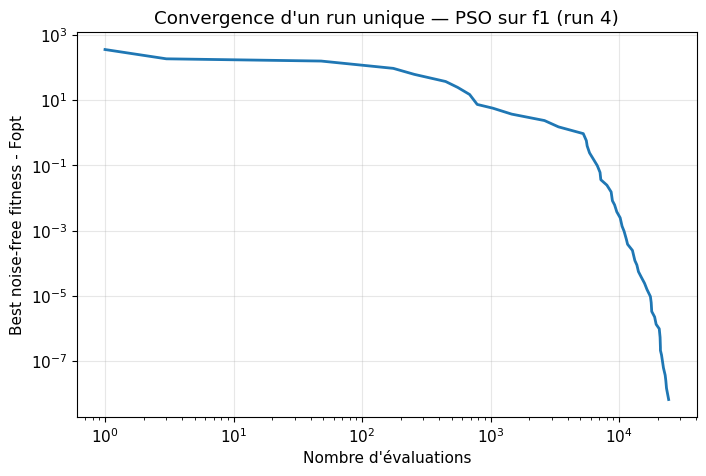

,evaluations,noise_free_fitness_minus_Fopt,best_noise_free_fitness_minus_Fopt,measured_fitness,best_measured_fitness,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,algorithm,problem,dimension,instance,run_id
158,1.0,357.500547,357.500547,205.460547,205.460547,2.23130,-4.44680,-4.7936,2.19340,-0.82279,4.06860,-2.066900,4.4692,2.97300,-2.54950,3.54090,2.20360,3.3581,-4.6803,-3.70260,-1.81300,0.89296,-0.21299,4.1563,1.49570,PSO,f1,20,NaN,4
159,3.0,185.491531,185.491531,33.451531,33.451531,-2.96940,-0.72032,-1.2120,0.17358,3.18820,-2.99390,-0.080634,-1.1921,2.10580,-3.18910,-1.75880,-3.15350,2.4073,4.9891,-4.54920,4.17180,1.80280,0.72086,1.5627,-0.75521,PSO,f1,20,NaN,4
160,48.0,158.448099,158.448099,6.408099,6.408099,-0.23955,0.21300,-4.4085,4.44270,0.76950,-3.05510,-1.071000,-1.8171,-0.70491,0.89203,-0.41518,-2.42640,1.6957,-4.6006,2.27470,-1.42550,0.98052,0.53719,-2.4164,0.89584,PSO,f1,20,NaN,4
161,175.0,94.571489,94.571489,-57.468511,-57.468511,-1.32410,2.28610,-1.7584,4.26350,-1.53810,0.68468,-0.192130,2.4174,0.77460,2.55780,-0.45997,1.96940,-3.0502,2.7220,-2.27620,-1.62000,5.00000,-2.10100,1.7333,2.37940,PSO,f1,20,NaN,4
162,255.0,61.874553,61.874553,-90.165447,-90.165447,-1.22670,2.37600,-4.7615,4.21550,-1.32260,0.47627,-2.674000,1.7318,0.47552,3.24600,-1.69050,-0.77859,-2.7123,2.6285,0.28164,-0.20371,2.59950,-0.68819,4.4867,4.17200,PSO,f1,20,NaN,4


,evaluations,noise_free_fitness_minus_Fopt,best_noise_free_fitness_minus_Fopt,measured_fitness,best_measured_fitness,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,x14,x15,x16,x17,x18,x19,x20,algorithm,problem,dimension,instance,run_id
207,22133.0,6.242684e-08,6.242684e-08,-152.04,-152.04,-0.26719,1.4240,-3.9249,3.2968,2.4192,0.15038,-0.87841,-0.70072,1.5,3.4808,-0.84391,-2.6416,-3.9087,3.8936,0.28407,1.2368,2.0505,0.29919,-0.36393,3.9513,PSO,f1,20,NaN,4
208,22832.0,3.718165e-08,3.718165e-08,-152.04,-152.04,-0.26725,1.4241,-3.9249,3.2968,2.4192,0.15044,-0.87840,-0.70076,1.5,3.4808,-0.84403,-2.6416,-3.9088,3.8936,0.28401,1.2368,2.0505,0.29916,-0.36394,3.9512,PSO,f1,20,NaN,4
209,23107.0,2.501983e-08,2.501983e-08,-152.04,-152.04,-0.26725,1.4240,-3.9249,3.2968,2.4192,0.15036,-0.87841,-0.70082,1.5,3.4808,-0.84394,-2.6416,-3.9088,3.8936,0.28403,1.2368,2.0504,0.29916,-0.36393,3.9512,PSO,f1,20,NaN,4
210,23379.0,1.480083e-08,1.480083e-08,-152.04,-152.04,-0.26719,1.4240,-3.9249,3.2968,2.4192,0.15040,-0.87843,-0.70082,1.5,3.4808,-0.84399,-2.6416,-3.9088,3.8937,0.28405,1.2368,2.0504,0.29920,-0.36397,3.9512,PSO,f1,20,NaN,4
211,24303.0,6.651248e-09,6.651248e-09,-152.04,-152.04,-0.26717,1.4240,-3.9248,3.2968,2.4192,0.15037,-0.87842,-0.70081,1.5,3.4808,-0.84400,-2.6416,-3.9088,3.8936,0.28403,1.2368,2.0504,0.29920,-0.36396,3.9512,PSO,f1,20,NaN,4


In [197]:
# ============================================================
# 9. ANALYSE D'UN RUN UNIQUE
# ============================================================

chosen_run_id = case_runs.sort_values("final_delta_f")["run_id"].iloc[0]  # meilleur run final
single_run = case_points[case_points["run_id"] == chosen_run_id].sort_values("evaluations")

plt.figure(figsize=(8, 5))
plt.plot(single_run["evaluations"], single_run["best_noise_free_fitness_minus_Fopt"], linewidth=2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title(f"Convergence d'un run unique — {CASE_ALGO} sur {CASE_PROBLEM} (run {chosen_run_id})")
plt.show()

display(single_run.head())
display(single_run.tail())

**Utilité générale de la courbe de convergence :** Une courbe de convergence montre l'évolution de la performance d'un algorithme au fil des évaluations, permettant d'observer la vitesse et la qualité de l'optimisation.

**Dans notre cas :** Cette courbe illustre la trajectoire d'un run unique de l'algorithme sur un problème BBOB, révélant les fluctuations stochastiques et la progression vers l'optimum. Elle sert à identifier des comportements atypiques ou des phases de stagnation, essentiels pour comprendre la dynamique de l'algorithme sur ce problème spécifique.

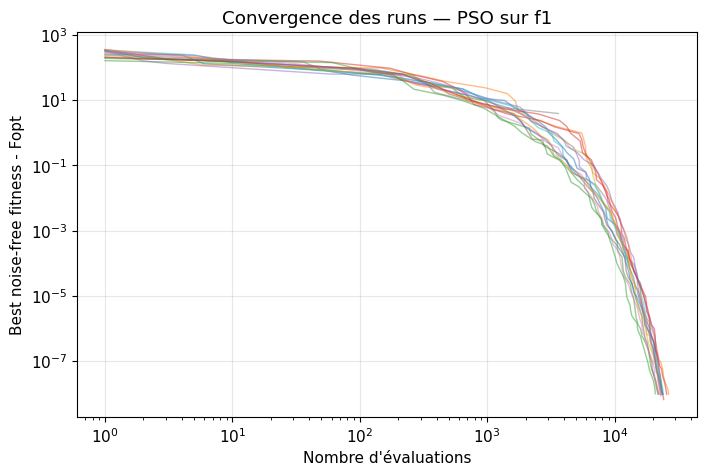

In [198]:
# ============================================================
# 10. ANALYSE MULTI-RUNS
# ============================================================

plt.figure(figsize=(8, 5))
for run_id, run_df in case_points.groupby("run_id"):
    run_df = run_df.sort_values("evaluations")
    plt.plot(
        run_df["evaluations"],
        run_df["best_noise_free_fitness_minus_Fopt"],
        alpha=0.5,
        linewidth=1
    )

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title(f"Convergence des runs — {CASE_ALGO} sur {CASE_PROBLEM}")
plt.show()

**Utilité générale de la courbe :** Une courbe de convergence montre l'évolution de la performance d'un algorithme au fil des évaluations, permettant d'observer la vitesse et la qualité de l'optimisation.

**Dans notre cas :** Cette courbe illustre la trajectoire d'un run unique de l'algorithme sur un problème BBOB, révélant les fluctuations stochastiques et la progression vers l'optimum. Elle sert à identifier des comportements atypiques ou des phases de stagnation, essentiels pour comprendre la dynamique de l'algorithme sur ce problème spécifique.

La superposition des runs permet d'évaluer la robustesse de l'algorithme. Des courbes proches indiquent une faible sensibilité à l'aléa, alors qu'une forte dispersion traduit un comportement stochastique important et une fiabilité plus faible sur ce problème.

## 11. Agrégation des runs : moyenne, médiane, IQR
Construction d'une courbe agrégée montrant la tendance centrale (moyenne et médiane) et la dispersion (intervalle interquartile) des performances.

## 12. Statistiques descriptives finales
Synthèse des métriques résumées : moyenne, médiane, écart-type, IQR et coefficient de variation pour le cas étudié.

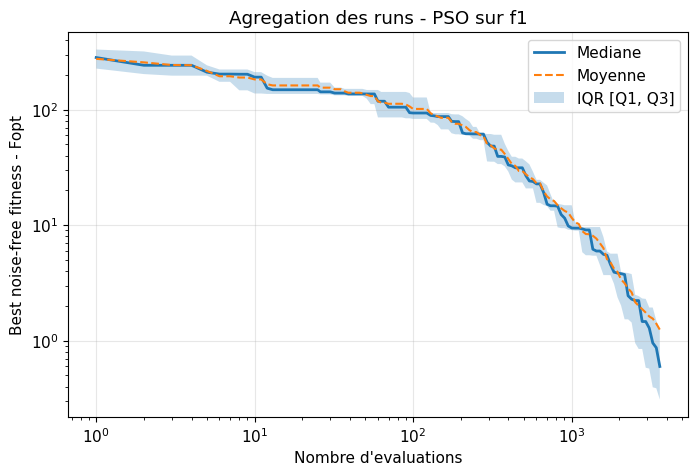

Budget commun utilise pour l'agregation affichee : 3614 evaluations


In [215]:
# ============================================================
# 11. AGREGER LES RUNS : MOYENNE, MEDIANE, IQR
# ============================================================

agg_case, curves_case, run_ids_case = aggregate_convergence(
    all_points,
    algorithm=CASE_ALGO,
    problem=CASE_PROBLEM
)

# On limite l'affichage au budget commun a tous les runs du cas d'etude.
# Cela evite qu'un run arrete plus tot fige artificiellement la moyenne
# et donne une impression visuelle de non-convergence de l'agregation.
common_eval_max = (
    case_points.groupby("run_id")["evaluations"]
    .max()
    .min()
)

agg_case_common = agg_case[agg_case["evaluations"] <= common_eval_max].copy()

plt.figure(figsize=(8, 5))
plt.plot(agg_case_common["evaluations"], agg_case_common["median"], label="Mediane", linewidth=2)
plt.plot(agg_case_common["evaluations"], agg_case_common["mean"], label="Moyenne", linestyle="--")
plt.fill_between(
    agg_case_common["evaluations"],
    agg_case_common["q25"],
    agg_case_common["q75"],
    alpha=0.25,
    label="IQR [Q1, Q3]"
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'evaluations")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title(f"Agregation des runs - {CASE_ALGO} sur {CASE_PROBLEM}")
plt.legend()
plt.show()

print(f"Budget commun utilise pour l'agregation affichee : {int(common_eval_max)} evaluations")


**Utilité de cette visualisation :** Cette courbe agrégée combine la médiane (ligne pleine), la moyenne (pointillée) et l'intervalle interquartile (zone ombrée) pour synthétiser les performances de tous les runs d'un algorithme sur un problème. La médiane représente la tendance centrale robuste, tandis que l'IQR montre la dispersion interquartile. Des écarts entre moyenne et médiane révèlent des distributions asymétriques, et un IQR étroit indique une bonne reproductibilité de l'algorithme.

In [200]:
# ============================================================
# 12. STATISTIQUES DESCRIPTIVES FINALES
# ============================================================

case_stats = case_runs["final_delta_f"].agg(["mean", "median", "min", "max", "std"]).to_frame().T
case_stats["iqr"] = iqr(case_runs["final_delta_f"].dropna())
case_stats["cv"] = case_stats["std"] / case_stats["mean"]

display(case_stats)

,mean,median,min,max,std,iqr,cv
final_delta_f,0.260477,9.661335e-09,6.651248e-09,3.907148,1.008821,3.163496e-10,3.872983


La médiane constitue ici un indicateur central robuste, particulièrement pertinent en présence de distributions asymétriques ou de runs atypiques. L'IQR complète cette lecture en mesurant la dispersion interquartile. Une moyenne proche de la médiane et un IQR faible suggèrent une bonne stabilité de l'algorithme sur le problème considéré.

## 13. ETAPE 2 - UN ALGORITHME SUR PLUSIEURS PROBLEMES
choix de l'algo


## Cellule 14 — Boxplots des performances finales par problème

In [201]:
# ============================================================
# 13. ETAPE 2 - UN ALGORITHME SUR PLUSIEURS PROBLEMES
# ============================================================

ALGO_MULTI = "PSO"

multi_runs = all_runs_summary[all_runs_summary["algorithm"] == ALGO_MULTI].copy()
multi_points = all_points[all_points["algorithm"] == ALGO_MULTI].copy()

display(multi_runs.head())

,algorithm,problem,dimension,run_id,instance,n_points,eval_min,eval_max,final_delta_f,best_delta_f
0,PSO,f1,20,1,NaN,53,1.0,23846.0,9.624287e-09,9.624287e-09
1,PSO,f1,20,2,NaN,53,1.0,26565.0,9.791108e-09,9.791108e-09
2,PSO,f1,20,3,NaN,52,1.0,21926.0,9.661335e-09,9.661335e-09
3,PSO,f1,20,4,NaN,54,1.0,24303.0,6.651248e-09,6.651248e-09
4,PSO,f1,20,5,NaN,54,1.0,23608.0,9.415011e-09,9.415011e-09


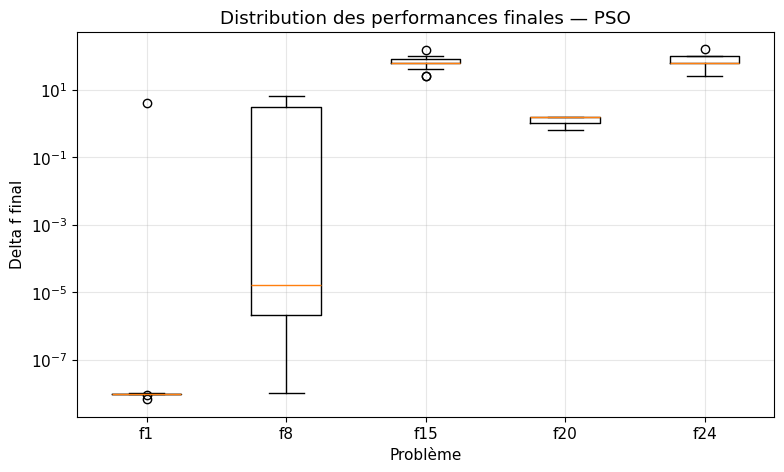

In [202]:
# ============================================================
# 14. BOXPLOTS PAR PROBLEME
# ============================================================

data_for_boxplot = [
    multi_runs[multi_runs["problem"] == pb]["final_delta_f"].dropna().values
    for pb in PROBLEMS
]

plt.figure(figsize=(9, 5))
plt.boxplot(data_for_boxplot, tick_labels=PROBLEMS)
plt.yscale("log")
plt.xlabel("Problème")
plt.ylabel("Delta f final")
plt.title(f"Distribution des performances finales — {ALGO_MULTI}")
plt.show()

## Cellule 15 — Courbes médianes par problème

**Utilité générale du boxplot :** Un boxplot visualise la distribution statistique d'un ensemble de données, montrant la médiane, les quartiles et les valeurs aberrantes pour comparer des groupes.

**Dans notre cas :** Ce boxplot compare les performances finales de l'algorithme PSO sur différents problèmes BBOB, révélant les problèmes où l'algorithme est le plus efficace (boîtes basses) ou rencontre des difficultés (boîtes hautes avec outliers). Il met en évidence la variabilité inter-problèmes et aide à prioriser les optimisations algorithmiques.

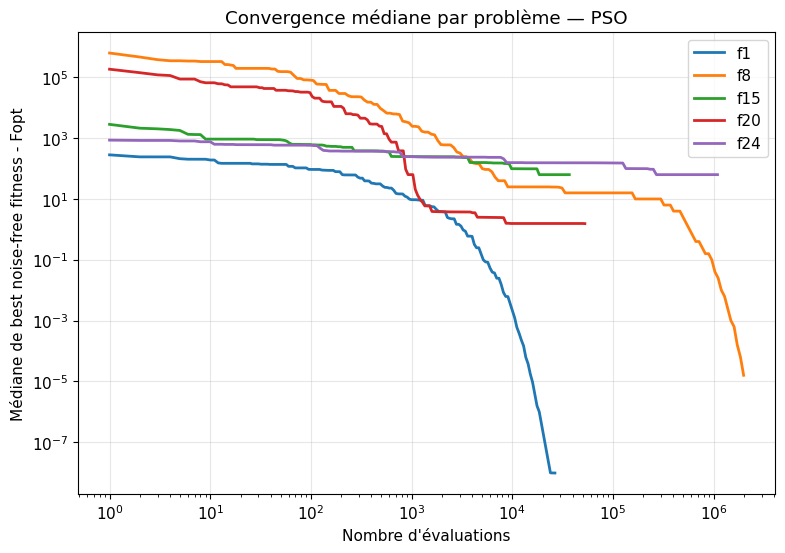

In [203]:
# ============================================================
# 15. COURBES DE CONVERGENCE MEDIANES PAR PROBLEME
# ============================================================

plt.figure(figsize=(9, 6))

for pb in PROBLEMS:
    agg_df, _, _ = aggregate_convergence(all_points, algorithm=ALGO_MULTI, problem=pb)
    plt.plot(agg_df["evaluations"], agg_df["median"], label=pb, linewidth=2)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Médiane de best noise-free fitness - Fopt")
plt.title(f"Convergence médiane par problème — {ALGO_MULTI}")
plt.legend()
plt.show()

## Cellule 16 — Heatmap des performances finales

**Utilité générale des courbes de convergence :** Ces courbes montrent l'évolution temporelle de la performance médiane d'un algorithme, permettant de comparer la vitesse de convergence sur différents problèmes.

**Dans notre cas :** Ces courbes médianes illustrent comment l'algorithme PSO converge différemment selon les problèmes BBOB, révélant des patterns de difficulté (convergence lente sur certains problèmes) et aidant à identifier les caractéristiques algorithmiques à améliorer pour une meilleure généralisation.

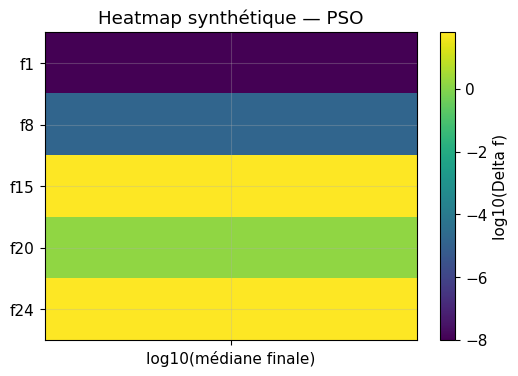

,median_final_delta_f,log10_median
problem,,
f1,9.661335e-09,-8.014963
f8,1.584792e-05,-4.800028
f15,6.297336e+01,1.799157
f20,1.545702e+00,0.189126
f24,6.308899e+01,1.799954


In [204]:
# ============================================================
# 16. HEATMAP DES PERFORMANCES FINALES
# ============================================================

heatmap_df = (
    multi_runs.groupby(["problem"])["final_delta_f"]
    .median()
    .reindex(PROBLEMS)
    .to_frame(name="median_final_delta_f")
)

heatmap_df["log10_median"] = np.log10(np.clip(heatmap_df["median_final_delta_f"], 1e-300, None))

plt.figure(figsize=(6, 4))
plt.imshow(heatmap_df[["log10_median"]].values, aspect="auto")
plt.yticks(range(len(PROBLEMS)), PROBLEMS)
plt.xticks([0], ["log10(médiane finale)"])
plt.colorbar(label="log10(Delta f)")
plt.title(f"Heatmap synthétique — {ALGO_MULTI}")
plt.show()

display(heatmap_df)

## Cellule 17 — ECDF par problème

**Utilité générale de la heatmap :** Une heatmap représente des valeurs numériques sous forme de couleurs, facilitant la visualisation de patterns dans des données multidimensionnelles.

**Dans notre cas :** Cette heatmap synthétique montre la performance médiane logarithmique de l'algorithme PSO sur chaque problème BBOB, permettant une comparaison visuelle rapide des difficultés relatives des problèmes et l'identification des cas où l'algorithme excelle ou peine.

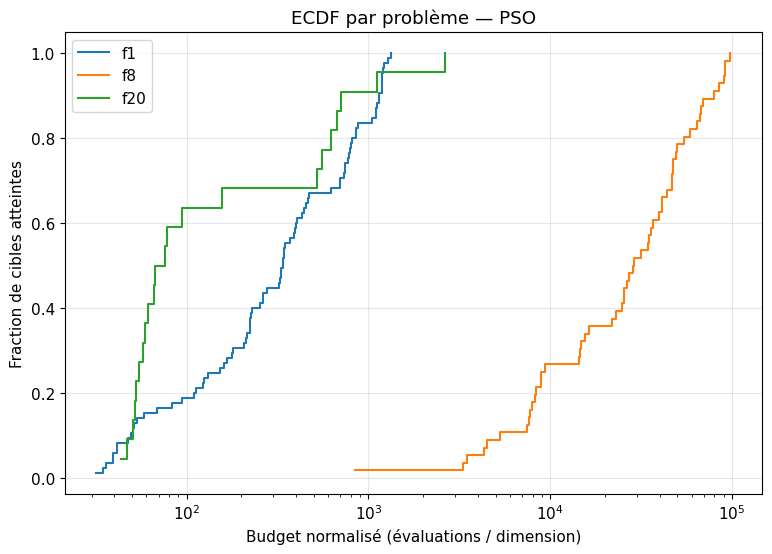

In [205]:
# ============================================================
# 17. ECDF PAR PROBLEME
# ============================================================

TARGETS = [1e1, 1e0, 1e-1, 1e-2, 1e-5, 1e-8]

def first_hitting_time(run_df, target, y_col="best_noise_free_fitness_minus_Fopt"):
    run_df = run_df.sort_values("evaluations")
    reached = run_df[run_df[y_col] <= target]
    if len(reached) == 0:
        return np.nan
    return reached["evaluations"].iloc[0]

def ecdf_curve_for_algo_problem(points_df, algorithm, problem, targets=TARGETS):
    subset = get_subset(points_df, algorithm=algorithm, problem=problem)
    times = []

    for run_id, run_df in subset.groupby("run_id"):
        for target in targets:
            t = first_hitting_time(run_df, target=target)
            if not np.isnan(t):
                times.append(t / DIMENSION)  # budget normalisé par la dimension

    if len(times) == 0:
        return np.array([]), np.array([])

    times = np.sort(np.array(times))
    y = np.arange(1, len(times) + 1) / len(times)
    return times, y

plt.figure(figsize=(9, 6))

for pb in PROBLEMS:
    x_ecdf, y_ecdf = ecdf_curve_for_algo_problem(all_points, ALGO_MULTI, pb)
    if len(x_ecdf) > 0:
        plt.step(x_ecdf, y_ecdf, where="post", label=pb)

plt.xscale("log")
plt.xlabel("Budget normalisé (évaluations / dimension)")
plt.ylabel("Fraction de cibles atteintes")
plt.title(f"ECDF par problème — {ALGO_MULTI}")
plt.legend()
plt.show()

**Utilité générale de l'ECDF :** L'Empirical Cumulative Distribution Function mesure la fraction de succès (atteinte de cibles de précision) en fonction du budget d'évaluations, permettant une évaluation probabiliste des performances.

**Dans notre cas :** Cette ECDF par problème montre la capacité de l'algorithme PSO à atteindre différentes cibles de précision (10^1 à 10^-8) sur chaque problème BBOB. Une courbe plus haute et plus à gauche indique une meilleure performance sur ce problème. Cette visualisation révèle les difficultés relatives des problèmes et aide à comprendre pourquoi certains problèmes sont plus faciles à optimiser que d'autres.

## 9. Étape 3 — Comparaison des 3 algorithmes
## Cellule 18 — Boxplots comparatifs sur un problème


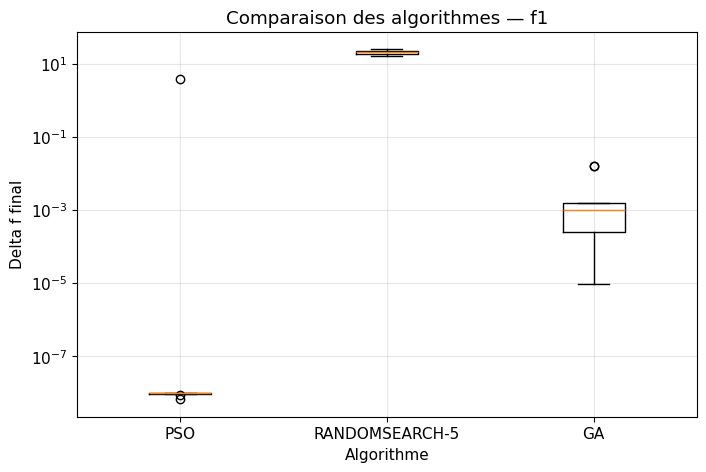

In [206]:
# ============================================================
# 18. COMPARAISON DES 3 ALGORITHMES SUR UN PROBLEME
# ============================================================

COMPARE_PROBLEM = "f1"

compare_df = all_runs_summary[all_runs_summary["problem"] == COMPARE_PROBLEM].copy()

data_for_boxplot = [
    compare_df[compare_df["algorithm"] == algo]["final_delta_f"].dropna().values
    for algo in ALGORITHMS
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_for_boxplot, tick_labels=ALGORITHMS)
plt.yscale("log")
plt.xlabel("Algorithme")
plt.ylabel("Delta f final")
plt.title(f"Comparaison des algorithmes — {COMPARE_PROBLEM}")
plt.show()

## Cellule 19 — Courbes médianes comparatives

**Utilité générale du boxplot comparatif :** Un boxplot comparatif permet de visualiser et comparer les distributions de performances entre plusieurs groupes ou catégories.

**Dans notre cas :** Ce boxplot compare les distributions des performances finales des trois algorithmes (PSO, GA, Random Search) sur le problème f1, révélant lequel est le plus efficace et le plus robuste. Les différences de médianes et de dispersions indiquent les forces relatives de chaque approche sur ce problème spécifique.

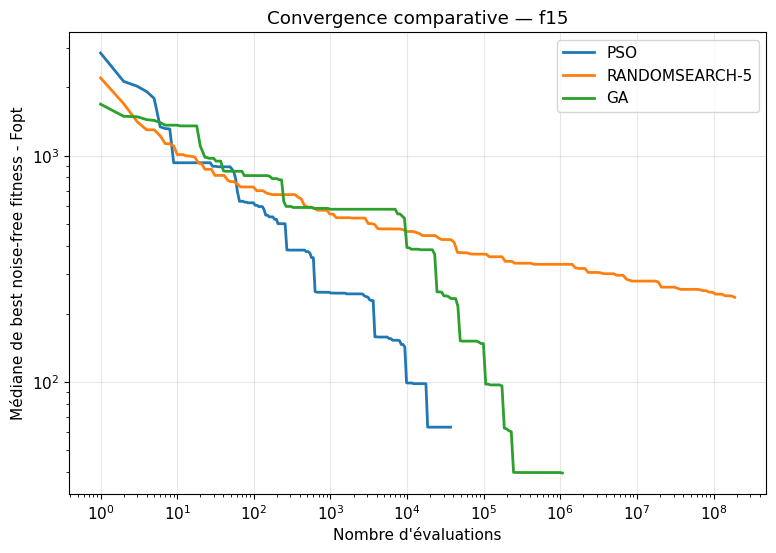

In [207]:
# ============================================================
# 19. COURBES DE CONVERGENCE COMPARATIVES
# ============================================================

COMPARE_PROBLEM = "f15"

plt.figure(figsize=(9, 6))

for algo in ALGORITHMS:
    agg_df, _, _ = aggregate_convergence(all_points, algorithm=algo, problem=COMPARE_PROBLEM)
    plt.plot(agg_df["evaluations"], agg_df["median"], label=algo, linewidth=2)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'évaluations")
plt.ylabel("Médiane de best noise-free fitness - Fopt")
plt.title(f"Convergence comparative — {COMPARE_PROBLEM}")
plt.legend()
plt.show()

## Cellule 20 — Heatmap algorithmes × problèmes

**Utilité générale des courbes comparatives :** Ces courbes permettent de comparer l'évolution temporelle des performances médianes de plusieurs algorithmes sur le même problème.

**Dans notre cas :** Ces courbes montrent comment les trois algorithmes convergent sur le problème f15, révélant leurs vitesses relatives et leurs comportements asymptotiques. Une courbe plus basse indique une meilleure performance, et la forme de la courbe révèle si l'algorithme stagne ou continue à s'améliorer avec plus d'évaluations.

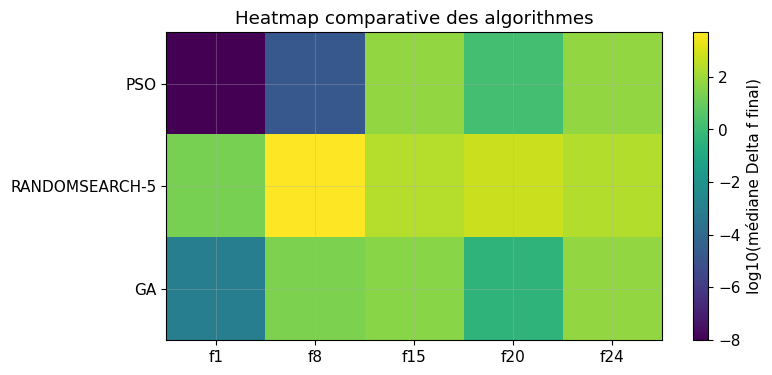

problem,f1,f8,f15,f20,f24
algorithm,,,,,
PSO,9.661335e-09,0.000016,62.973364,1.545702,63.088987
RANDOMSEARCH-5,2.038579e+01,4966.224993,236.131221,550.997943,227.714290
GA,9.937241e-04,24.329132,39.476878,0.395387,62.627005


In [208]:
# ============================================================
# 20. HEATMAP ALGORITHMES x PROBLEMES
# ============================================================

perf_table = (
    all_runs_summary.groupby(["algorithm", "problem"])["final_delta_f"]
    .median()
    .unstack()
    .reindex(index=ALGORITHMS, columns=PROBLEMS)
)

perf_table_log = np.log10(np.clip(perf_table, 1e-300, None))

plt.figure(figsize=(8, 4))
plt.imshow(perf_table_log.values, aspect="auto")
plt.xticks(range(len(PROBLEMS)), PROBLEMS)
plt.yticks(range(len(ALGORITHMS)), ALGORITHMS)
plt.colorbar(label="log10(médiane Delta f final)")
plt.title("Heatmap comparative des algorithmes")
plt.show()

display(perf_table)

## Cellule 21 — Meilleur algorithme par problème

**Utilité générale de la heatmap comparative :** Une heatmap matricielle facilite la comparaison de performances croisées entre deux dimensions (ici algorithmes et problèmes).

**Dans notre cas :** Cette heatmap révèle les forces et faiblesses relatives de chaque algorithme sur chaque problème BBOB, permettant d'identifier les spécialisations algorithmiques. Les zones sombres indiquent de bonnes performances, et les patterns diagonaux ou par blocs suggèrent des complémentarités entre algorithmes.

In [209]:
# ============================================================
# 21. MEILLEUR ALGORITHME PAR PROBLEME
# ============================================================

best_algo_by_problem = perf_table.idxmin(axis=0).to_frame(name="best_algorithm")
best_algo_by_problem["best_value"] = perf_table.min(axis=0).values

display(best_algo_by_problem)

,best_algorithm,best_value
problem,,
f1,PSO,9.661335e-09
f8,PSO,1.584792e-05
f15,GA,3.947688e+01
f20,GA,3.953873e-01
f24,GA,6.262700e+01


## Cellule 22 — ECDF globale comparative

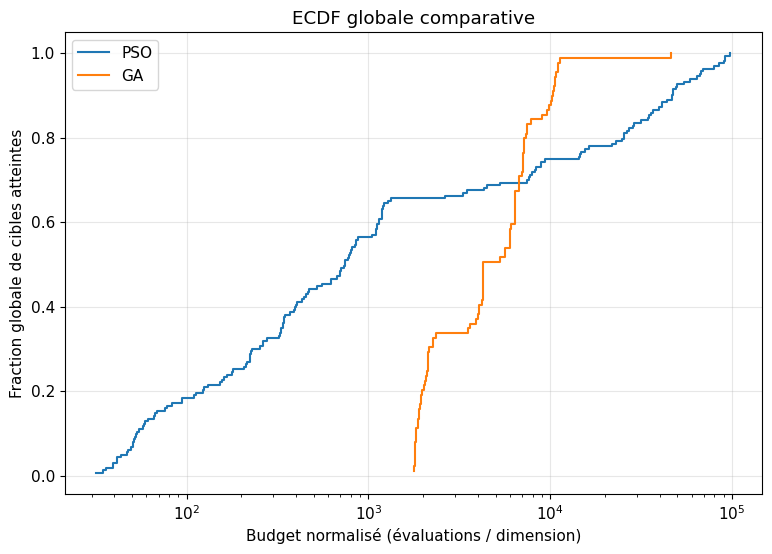

In [210]:
# ============================================================
# 22. ECDF GLOBALE COMPARATIVE
# ============================================================

def ecdf_curve_global(points_df, algorithm, problems=PROBLEMS, targets=TARGETS):
    times = []

    for pb in problems:
        subset = get_subset(points_df, algorithm=algorithm, problem=pb)
        for run_id, run_df in subset.groupby("run_id"):
            for target in targets:
                t = first_hitting_time(run_df, target=target)
                if not np.isnan(t):
                    times.append(t / DIMENSION)

    if len(times) == 0:
        return np.array([]), np.array([])

    times = np.sort(np.array(times))
    y = np.arange(1, len(times) + 1) / len(times)
    return times, y

plt.figure(figsize=(9, 6))

for algo in ALGORITHMS:
    x_ecdf, y_ecdf = ecdf_curve_global(all_points, algo)
    if len(x_ecdf) > 0:
        plt.step(x_ecdf, y_ecdf, where="post", label=algo)

plt.xscale("log")
plt.xlabel("Budget normalisé (évaluations / dimension)")
plt.ylabel("Fraction globale de cibles atteintes")
plt.title("ECDF globale comparative")
plt.legend()
plt.show()

**Utilité de cette visualisation :** Cette courbe ECDF (Empirical Cumulative Distribution Function) globale compare la performance des trois algorithmes sur l'ensemble des problèmes BBOB en agrégeant tous les runs et toutes les cibles. Elle montre la fraction de cibles atteintes en fonction du budget normalisé (évaluations par dimension). Un algorithme qui atteint plus rapidement une fraction donnée de cibles (courbe plus à gauche) est considéré comme plus efficace. Cette vue d'ensemble permet d'évaluer la robustesse globale de chaque approche sur le benchmark complet.

## 10. Tableau de recommandation par budget

## Cellule 23 — Recommandation par problème et budget

In [211]:
# ============================================================
# 23. TABLEAU DE RECOMMANDATION PAR BUDGET
# ============================================================

def value_at_budget(run_df, budget, y_col="best_noise_free_fitness_minus_Fopt"):
    run_df = run_df.sort_values("evaluations")
    eligible = run_df[run_df["evaluations"] <= budget]
    if len(eligible) == 0:
        return np.nan
    return eligible[y_col].iloc[-1]

recommendation_rows = []

for pb in PROBLEMS:
    for budget_name, budget_value in BUDGET_LEVELS.items():
        algo_scores = {}
        for algo in ALGORITHMS:
            subset = get_subset(all_points, algorithm=algo, problem=pb)
            vals = []
            for run_id, run_df in subset.groupby("run_id"):
                v = value_at_budget(run_df, budget_value)
                if not np.isnan(v):
                    vals.append(v)

            algo_scores[algo] = np.median(vals) if len(vals) > 0 else np.nan

        best_algo = min(algo_scores, key=lambda k: np.inf if np.isnan(algo_scores[k]) else algo_scores[k])

        recommendation_rows.append({
            "problem": pb,
            "budget_name": budget_name,
            "budget_value": budget_value,
            "recommended_algorithm": best_algo,
            **{f"score_{algo}": algo_scores[algo] for algo in ALGORITHMS}
        })

recommendation_table = pd.DataFrame(recommendation_rows)
display(recommendation_table)

,problem,budget_name,budget_value,recommended_algorithm,score_PSO,score_RANDOMSEARCH-5,score_GA
0,f1,petit,2000,PSO,3.848068e+00,75.080856,89.697220
1,f1,moyen,20000,PSO,3.932338e-07,61.102073,34.570504
2,f1,grand,200000,PSO,9.661335e-09,49.433597,0.015585
3,f8,petit,2000,PSO,6.130551e+02,58807.062130,78344.240330
4,f8,moyen,20000,PSO,2.491730e+01,30640.069820,14553.657560
5,f8,grand,200000,PSO,9.998164e+00,21574.081870,24.806030
6,f15,petit,2000,PSO,2.445674e+02,529.161469,578.950632
7,f15,moyen,20000,PSO,6.297336e+01,442.906120,383.282766
8,f15,grand,200000,GA,6.297336e+01,340.637598,60.701541
9,f20,petit,2000,PSO,3.799899e+00,16495.553740,23073.217520


Le tableau de recommandation condense l’analyse comparative en une règle de décision simple : pour chaque problème et pour chaque niveau de budget, on retient l’algorithme dont la performance agrégée médiane est la meilleure. Cette synthèse permet de passer d’une logique purement descriptive à une logique de sélection d’algorithme, conformément à l’objectif de recommandation interprétable.

## 11. Tests statistiques

In [212]:
# ============================================================
# 25. TESTS STATISTIQUES : WILCOXON APPARIE
# ============================================================

def paired_problem_medians(runs_summary_df, algo_a, algo_b, problems=PROBLEMS):
    rows = []
    for pb in problems:
        a_vals = runs_summary_df[
            (runs_summary_df["algorithm"] == algo_a) &
            (runs_summary_df["problem"] == pb)
        ]["final_delta_f"].dropna()

        b_vals = runs_summary_df[
            (runs_summary_df["algorithm"] == algo_b) &
            (runs_summary_df["problem"] == pb)
        ]["final_delta_f"].dropna()

        if len(a_vals) == 0 or len(b_vals) == 0:
            continue

        rows.append({
            "problem": pb,
            "median_a": np.median(a_vals),
            "median_b": np.median(b_vals)
        })

    return pd.DataFrame(rows)

pairs = [
    ("PSO", "RANDOMSEARCH-5"),
    ("PSO", "GA"),
    ("GA", "RANDOMSEARCH-5")
]

wilcoxon_rows = []

for algo_a, algo_b in pairs:
    pair_df = paired_problem_medians(all_runs_summary, algo_a, algo_b)
    if len(pair_df) >= 1:
        try:
            stat, pval = wilcoxon(pair_df["median_a"], pair_df["median_b"])
        except ValueError:
            stat, pval = np.nan, np.nan

        wins_a = int((pair_df["median_a"] < pair_df["median_b"]).sum())
        wins_b = int((pair_df["median_b"] < pair_df["median_a"]).sum())
        ties = int((pair_df["median_a"] == pair_df["median_b"]).sum())

        wilcoxon_rows.append({
            "algo_a": algo_a,
            "algo_b": algo_b,
            "wins_a": wins_a,
            "wins_b": wins_b,
            "ties": ties,
            "wilcoxon_stat": stat,
            "p_value": pval
        })

wilcoxon_table = pd.DataFrame(wilcoxon_rows)
display(wilcoxon_table)

,algo_a,algo_b,wins_a,wins_b,ties,wilcoxon_stat,p_value
0,PSO,RANDOMSEARCH-5,5,0,0,0.0,0.0625
1,PSO,GA,2,3,0,6.0,0.8125
2,GA,RANDOMSEARCH-5,5,0,0,0.0,0.0625


## 12.Exports pour rapports scientifique 

In [213]:
# ============================================================
# 26. EXPORTS
# ============================================================

output_dir = Path("outputs_bbob_analysis")
output_dir.mkdir(exist_ok=True)

all_runs_summary.to_csv(output_dir / "all_runs_summary.csv", index=False)
perf_table.to_csv(output_dir / "performance_table_median_final_delta_f.csv")
recommendation_table.to_csv(output_dir / "recommendation_table.csv", index=False)
wilcoxon_table.to_csv(output_dir / "wilcoxon_table.csv", index=False)

print(f"Fichiers exportés dans : {output_dir.resolve()}")

Fichiers exportés dans : C:\Users\ouiss\OneDrive\Desktop\INGD\Recherche\code_analyse_algo\outputs_bbob_analysis


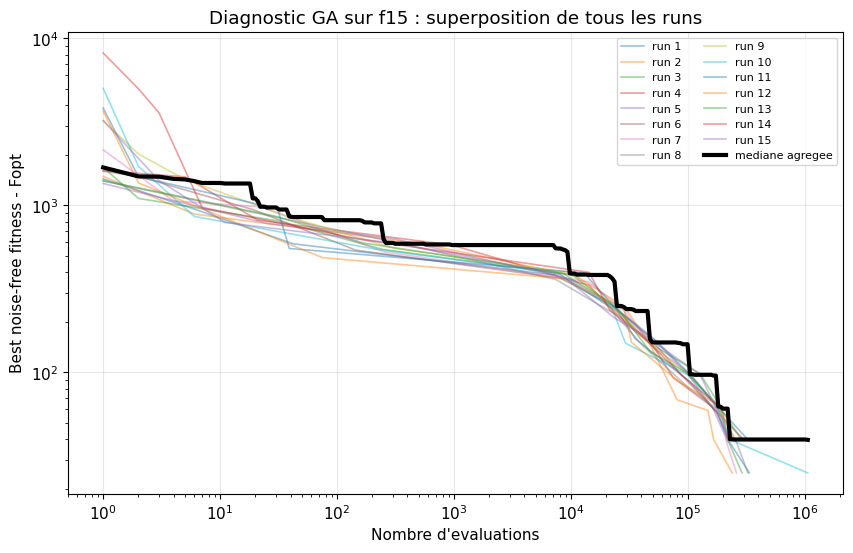

,n_points,eval_min,eval_max,start_value,final_value,best_value,worst_value,improvement_ratio
run_id,,,,,,,,
2,10,1.0,239989.0,1491.538253,24.995103,24.995103,1491.538253,59.673219
8,10,1.0,327220.0,1398.424236,25.007677,25.007677,1398.424236,55.919798
10,11,1.0,1061221.0,5016.568753,25.016707,25.016707,5016.568753,200.528739
7,11,1.0,260552.0,2149.985024,25.039676,25.039676,2149.985024,85.863132
3,11,1.0,290202.0,1687.399316,25.092797,25.092797,1687.399316,67.246361
1,10,1.0,334570.0,1441.204591,25.112588,25.112588,1441.204591,57.389728
5,9,1.0,219261.0,1352.136811,38.559517,38.559517,1352.136811,35.066228
6,10,1.0,226415.0,1602.751917,39.476878,39.476878,1602.751917,40.599764
13,9,1.0,286116.0,1408.352249,39.668399,39.668399,1408.352249,35.503128


Lecture conseillee : si presque tous les runs descendent mais que la mediane remonte localement, cela vient souvent d'un effet d'aggregation/interpolation ou d'une forte dispersion entre runs.


In [214]:
# ============================================================
# 27. DIAGNOSTIC DES RUNS GA SUR F15
# ============================================================

DIAG_ALGO = "GA"
DIAG_PROBLEM = "f15"
DIAG_Y_COL = "best_noise_free_fitness_minus_Fopt"

diag_points = get_subset(all_points, algorithm=DIAG_ALGO, problem=DIAG_PROBLEM).copy()

if diag_points.empty:
    raise ValueError(f"Aucune donnee disponible pour {DIAG_ALGO} sur {DIAG_PROBLEM}.")

plt.figure(figsize=(10, 6))

for run_id, run_df in diag_points.groupby("run_id"):
    run_df = run_df.sort_values("evaluations")
    plt.plot(
        run_df["evaluations"],
        run_df[DIAG_Y_COL],
        linewidth=1.2,
        alpha=0.45,
        label=f"run {run_id}"
    )

median_diag, _, _ = aggregate_convergence(
    all_points,
    algorithm=DIAG_ALGO,
    problem=DIAG_PROBLEM,
    y_col=DIAG_Y_COL,
    n_grid=300,
)

plt.plot(
    median_diag["evaluations"],
    median_diag["median"],
    color="black",
    linewidth=3,
    label="mediane agregee"
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Nombre d'evaluations")
plt.ylabel("Best noise-free fitness - Fopt")
plt.title("Diagnostic GA sur f15 : superposition de tous les runs")
plt.legend(ncol=2, fontsize=8)
plt.show()

diag_summary = (
    diag_points.sort_values(["run_id", "evaluations"])
    .groupby("run_id")
    .agg(
        n_points=("evaluations", "size"),
        eval_min=("evaluations", "min"),
        eval_max=("evaluations", "max"),
        start_value=(DIAG_Y_COL, "first"),
        final_value=(DIAG_Y_COL, "last"),
        best_value=(DIAG_Y_COL, "min"),
        worst_value=(DIAG_Y_COL, "max"),
    )
    .sort_values("final_value")
)

diag_summary["improvement_ratio"] = diag_summary["start_value"] / np.clip(diag_summary["final_value"], 1e-300, None)
display(diag_summary)

print("Lecture conseillee : si presque tous les runs descendent mais que la mediane remonte localement, cela vient souvent d'un effet d'aggregation/interpolation ou d'une forte dispersion entre runs.")
